In [1]:
# ==============================================================================
# 1. ADVANCED ENVIRONMENT SETUP & OPTIMIZATIONS
# ==============================================================================
import os
import gc
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from IPython.display import display, clear_output

import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import load_model
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc, precision_recall_curve)
from IPython.display import Image, display

In [2]:
# Enable Mixed Precision for 2x-3x speedup on Colab T4 GPUs
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f"Compute dtype: {policy.compute_dtype}")
print(f"Variable dtype: {policy.variable_dtype}")

# Set beautiful seaborn theme for charts
sns.set_theme(style="whitegrid", palette="muted")

# Mount Drive and Set Paths
drive.mount('/content/drive')
OUTPUT_DIR = '/content/drive/MyDrive/MLProject/Output'

for ds in ['Dataset1', 'Dataset2']:
    for model_name in ['Basic_CNN', 'Zhang_CNN', 'VGG16_FineTuned']:
        os.makedirs(os.path.join(OUTPUT_DIR, ds, model_name), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'Comparisons'), exist_ok=True)

# Global Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # Increased batch size due to mixed precision memory savings
EPOCHS = 20

Compute dtype: float16
Variable dtype: float32
Mounted at /content/drive


In [13]:
!ls -l "/content/drive/MyDrive/MLProject/Data/Dataset1/"
!ls -l "/content/drive/MyDrive/MLProject/Data/Dataset2/"

total 235707
-rw------- 1 root root 241363336 Feb 13  2020 'Concrete Crack Images for Classification.rar'
total 55514
-rw------- 1 root root 18706382 Aug  7  2019 picture1.zip
-rw------- 1 root root 19012436 Aug  7  2019 picture2.zip
-rw------- 1 root root 19054375 Aug  7  2019 picture3.zip
-rw------- 1 root root    57216 Aug  7  2019 train.txt
-rw------- 1 root root    14501 Aug  7  2019 val.txt


In [4]:
# ==============================================================================
# 2. FAST LOCAL DATA EXTRACTION (Crucial for GPU utilization)
# ==============================================================================
print("\nExtracting datasets to fast local Colab NVMe storage...")

# Dataset 1
DS1_RAR_PATH = '/content/drive/MyDrive/MLProject/Data/Dataset1/Concrete Crack Images for Classification.rar'
DS1_LOCAL_DIR = '/content/Dataset1'
if not os.path.exists(DS1_LOCAL_DIR):
    os.makedirs(DS1_LOCAL_DIR)
    !unrar x "{DS1_RAR_PATH}" "{DS1_LOCAL_DIR}/" > /dev/null
    print("Dataset 1 Extracted successfully.")

# Dataset 2
DS2_LOCAL_DIR = '/content/Dataset2'
DS2_IMAGES_DIR = os.path.join(DS2_LOCAL_DIR, 'images')
if not os.path.exists(DS2_LOCAL_DIR):
    os.makedirs(DS2_IMAGES_DIR, exist_ok=True)
    !unzip -q '/content/drive/MyDrive/MLProject/Data/Dataset2/picture1.zip' -d "{DS2_IMAGES_DIR}"
    !unzip -q '/content/drive/MyDrive/MLProject/Data/Dataset2/picture2.zip' -d "{DS2_IMAGES_DIR}"
    !unzip -q '/content/drive/MyDrive/MLProject/Data/Dataset2/picture3.zip' -d "{DS2_IMAGES_DIR}"
    shutil.copy('/content/drive/MyDrive/MLProject/Data/Dataset2/train.txt', DS2_LOCAL_DIR)
    shutil.copy('/content/drive/MyDrive/MLProject/Data/Dataset2/val.txt', DS2_LOCAL_DIR)
    print("Dataset 2 Extracted successfully.")


Extracting datasets to fast local Colab NVMe storage...
Dataset 1 Extracted successfully.
Dataset 2 Extracted successfully.


In [6]:
# ==============================================================================
# 3. HIGH-PERFORMANCE DATA PIPELINES (tf.data) WITH VERBOSE LOGGING
# ==============================================================================
AUTOTUNE = tf.data.AUTOTUNE

def get_dataset1():
    print("\n" + "="*50)
    print("📦 PREPARING DATASET 1 PIPELINE")
    print("="*50)

    data_dir = DS1_LOCAL_DIR
    subdirs = [os.path.join(data_dir, d) for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    if len(subdirs) == 1: data_dir = subdirs[0] # Step into inner folder if it exists

    # --- 1. LOGGING: Physical Disk Structure and Counts ---
    print(f"\n🔍 SCANNING RAW DIRECTORY: {data_dir}")
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    total_images_on_disk = 0

    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        num_files = len(os.listdir(cls_path))
        total_images_on_disk += num_files
        print(f"   ├── Folder '{cls}/' contains: {num_files} images")
    print(f"   └── TOTAL IMAGES ON DISK: {total_images_on_disk}")

    # --- 2. LOGGING: TensorFlow Pipeline Allocation ---
    print("\n⚙️ KERAS PIPELINE LOADING (80/20 Train/Val Split):")

    train_ds = image_dataset_from_directory(
        data_dir, validation_split=0.2, subset="training", seed=42,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

    val_ds = image_dataset_from_directory(
        data_dir, validation_split=0.2, subset="validation", seed=42,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

    # --- 3. LOGGING: Verification ---
    print(f"\n✅ PIPELINE VERIFICATION:")
    print(f"   ├── Total batches in Train pipeline: {len(train_ds)} (approx {len(train_ds) * BATCH_SIZE} images)")
    print(f"   └── Total batches in Val pipeline: {len(val_ds)} (approx {len(val_ds) * BATCH_SIZE} images)")

    return train_ds.prefetch(buffer_size=AUTOTUNE), val_ds.prefetch(buffer_size=AUTOTUNE)

def get_dataset2():
    print("\n" + "="*50)
    print("📦 PREPARING DATASET 2 PIPELINE")
    print("="*50)

    # --- 1. LOGGING: Physical Disk Structure and Counts ---
    print(f"\n🔍 SCANNING RAW DIRECTORY: {DS2_LOCAL_DIR}")
    images_on_disk = len(os.listdir(DS2_IMAGES_DIR)) if os.path.exists(DS2_IMAGES_DIR) else 0
    print(f"   ├── Folder 'images/' contains: {images_on_disk} extracted images")
    print(f"   ├── 'train.txt' found: {os.path.exists(os.path.join(DS2_LOCAL_DIR, 'train.txt'))}")
    print(f"   └── 'val.txt' found: {os.path.exists(os.path.join(DS2_LOCAL_DIR, 'val.txt'))}")

    def parse_txt(txt_path):
        paths, labels = [], []
        if os.path.exists(txt_path):
            with open(txt_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 2:
                        paths.append(os.path.join(DS2_IMAGES_DIR, parts[0]))
                        labels.append(float(parts[1]))
        return paths, labels

    train_paths, train_labels = parse_txt(os.path.join(DS2_LOCAL_DIR, 'train.txt'))
    val_paths, val_labels = parse_txt(os.path.join(DS2_LOCAL_DIR, 'val.txt'))

    # --- 2. LOGGING: Parsing Labels vs Disk Counts ---
    total_parsed = len(train_paths) + len(val_paths)
    print("\n⚙️ LABEL MAPPING (from txt files):")
    print(f"   ├── Images assigned to Training: {len(train_paths)}")
    print(f"   ├── Images assigned to Validation: {len(val_paths)}")
    print(f"   └── TOTAL LABELED IMAGES: {total_parsed}")

    # --- 3. LOGGING: Verification ---
    print(f"\n✅ PIPELINE VERIFICATION:")
    if total_parsed != images_on_disk:
        print(f"   ⚠️ NOTE: Number of labeled images ({total_parsed}) differs from raw images in folder ({images_on_disk}).")
        print(f"   ⚠️ The pipeline will strictly use only the {total_parsed} images explicitly listed in the .txt files.")
    else:
        print("   ✅ The number of labeled images perfectly matches the number of extracted images on disk.")

    print("\n🚀 Building tf.data Pipelines...")
    def load_and_preprocess(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, IMG_SIZE)
        return image, label

    train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    train_ds = train_ds.shuffle(buffer_size=2000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return train_ds, val_ds

In [7]:
# ==============================================================================
# 4. ADVANCED MODEL ARCHITECTURES
# ==============================================================================

def build_basic_cnn():
    """Enhanced Basic CNN with Batch Normalization to prevent vanishing gradients."""
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.Rescaling(1./255),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        # Final layer MUST be float32 when using mixed precision
        layers.Dense(1, activation='sigmoid', dtype='float32')
    ], name="Basic_CNN")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_zhang_cnn():
    """Zhang Architecture with precise standard layers."""
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.Rescaling(1./255),
        layers.Conv2D(48, (11, 11), strides=4, activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),
        layers.BatchNormalization(),

        layers.Conv2D(128, (5, 5), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),
        layers.BatchNormalization(),

        layers.Conv2D(192, (3, 3), padding='same', activation='relu'),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid', dtype='float32')
    ], name="Zhang_CNN")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_vgg16_finetuned():
    """VGG16 with Fine-tuning (Unfreezing top block for domain adaptation)."""
    base_model = applications.VGG16(weights='imagenet', include_top=False,
                                    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    # Freeze all blocks except the last one (block5) for fine-tuning
    for layer in base_model.layers:
        if 'block5' in layer.name:
            layer.trainable = True
        else:
            layer.trainable = False

    model = models.Sequential([
        # FIX: Wrapped the raw function inside a keras.layers.Lambda layer
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.Lambda(lambda x: applications.vgg16.preprocess_input(x)),
        base_model,
        layers.GlobalAveragePooling2D(),     # Replaces Flatten() to prevent overfitting
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid', dtype='float32')
    ], name="VGG16_FineTuned")

    # Lower learning rate for fine-tuning to prevent destroying pre-trained weights
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [8]:
# ==============================================================================
# 5. BEAUTIFUL INLINE VISUALIZATION FUNCTIONS
# ==============================================================================

def plot_training_history(history, save_path, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Accuracy
    sns.lineplot(ax=axes[0], data=history.history['accuracy'], label='Train Acc', linewidth=2)
    sns.lineplot(ax=axes[0], data=history.history['val_accuracy'], label='Val Acc', linewidth=2)
    axes[0].set_title(f'{model_name} - Accuracy Progression', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')

    # Loss
    sns.lineplot(ax=axes[1], data=history.history['loss'], label='Train Loss', linewidth=2)
    sns.lineplot(ax=axes[1], data=history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_title(f'{model_name} - Loss Progression', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')

    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f'{model_name}_history.png'), dpi=300)
    plt.show() # DISPLAY IN CELL

def plot_confusion_matrix_inline(y_true, y_pred, save_path, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['Non-Cracked', 'Cracked'],
                yticklabels=['Non-Cracked', 'Cracked'],
                annot_kws={"size": 14, "weight": "bold"})
    plt.title(f'Confusion Matrix - {model_name}', fontsize=15, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f'{model_name}_cm.png'), dpi=300)
    plt.show() # DISPLAY IN CELL

def plot_combined_roc_curves(dataset_name, roc_data, save_path):
    plt.figure(figsize=(10, 8))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    # FIX: Correctly unpacking the roc_data dictionary
    for (model_name, (y_true, y_probs)), color in zip(roc_data.items(), colors):
        fpr, tpr, _ = roc_curve(y_true, y_probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'Combined ROC curves for {dataset_name}', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig(os.path.join(save_path, f'{dataset_name}_Combined_ROC.png'), dpi=300)
    plt.show()


📦 PREPARING DATASET 1 PIPELINE

🔍 SCANNING RAW DIRECTORY: /content/Dataset1
   ├── Folder 'Negative/' contains: 20000 images
   ├── Folder 'Positive/' contains: 20000 images
   └── TOTAL IMAGES ON DISK: 40000

⚙️ KERAS PIPELINE LOADING (80/20 Train/Val Split):
Found 40000 files belonging to 2 classes.
Using 32000 files for training.
Found 40000 files belonging to 2 classes.
Using 8000 files for validation.

✅ PIPELINE VERIFICATION:
   ├── Total batches in Train pipeline: 1000 (approx 32000 images)
   └── Total batches in Val pipeline: 250 (approx 8000 images)

📦 PREPARING DATASET 2 PIPELINE

🔍 SCANNING RAW DIRECTORY: /content/Dataset2
   ├── Folder 'images/' contains: 6070 extracted images
   ├── 'train.txt' found: True
   └── 'val.txt' found: True

⚙️ LABEL MAPPING (from txt files):
   ├── Images assigned to Training: 4856
   ├── Images assigned to Validation: 1213
   └── TOTAL LABELED IMAGES: 6069

✅ PIPELINE VERIFICATION:
   ⚠️ NOTE: Number of labeled images (6069) differs from raw

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


📊 Replaying training logs from saved history (18 epochs):
Epoch 1/18 ━━━━━━━━━━━━━━━━━━━━ loss: 0.6271 - accuracy: 0.9439 - val_loss: 0.4339 - val_accuracy: 0.5579
Epoch 2/18 ━━━━━━━━━━━━━━━━━━━━ loss: 0.1032 - accuracy: 0.9515 - val_loss: 0.2082 - val_accuracy: 0.8842
Epoch 3/18 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0810 - accuracy: 0.9610 - val_loss: 0.0670 - val_accuracy: 0.9772
Epoch 4/18 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0694 - accuracy: 0.9701 - val_loss: 0.2834 - val_accuracy: 0.9099
Epoch 5/18 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0581 - accuracy: 0.9753 - val_loss: 0.6890 - val_accuracy: 0.9093
Epoch 6/18 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0345 - accuracy: 0.9846 - val_loss: 0.4716 - val_accuracy: 0.9581
Epoch 7/18 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0299 - accuracy: 0.9868 - val_loss: 0.1190 - val_accuracy: 0.9811
Epoch 8/18 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0218 - accuracy: 0.9907 - val_loss: 0.0506 - val_accuracy: 0.9914
Epoch 9/18 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0186 - accuracy: 0.9911 - val_loss: 0.0851 - val_accur

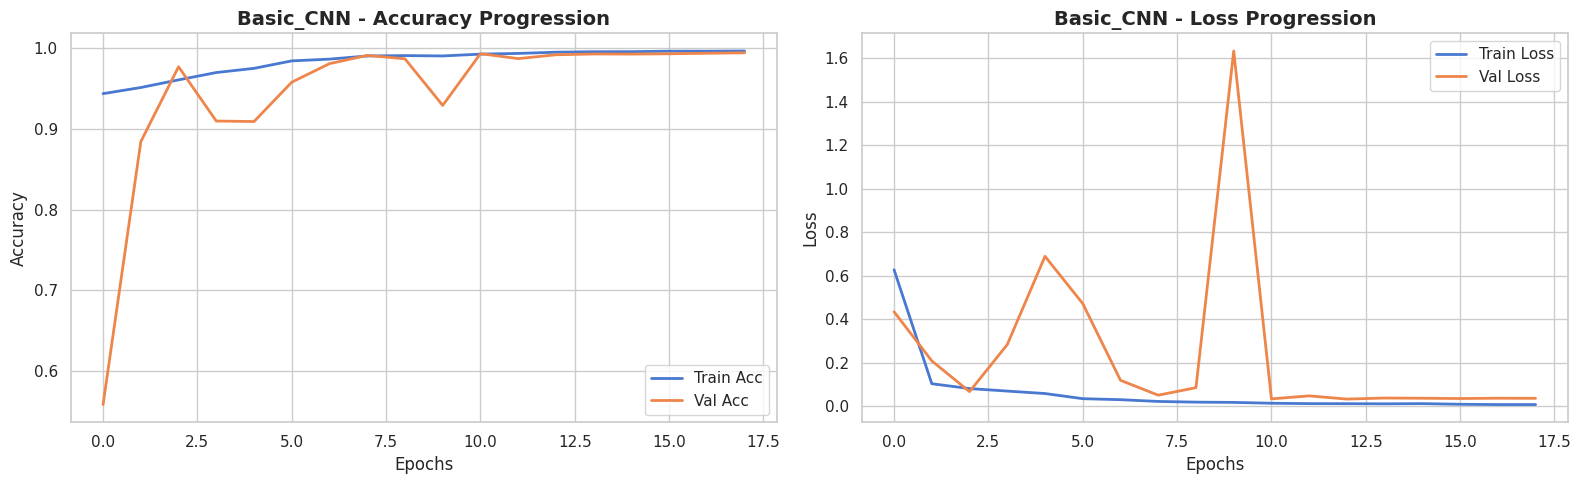

Extracting predictions for evaluation...


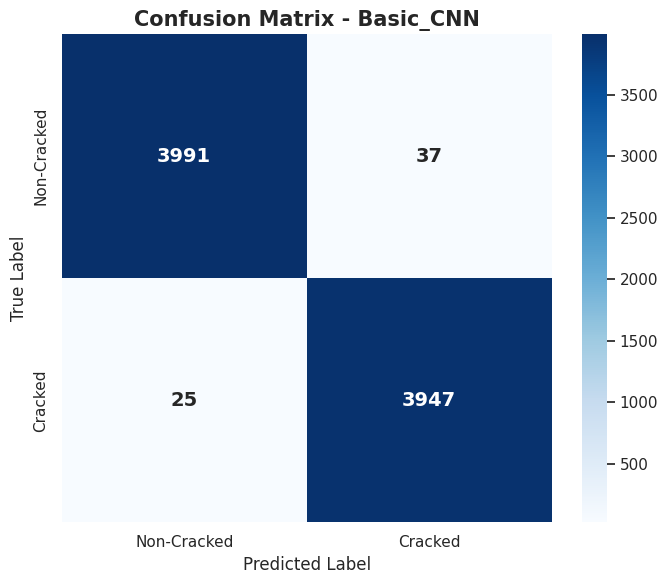


✅ Basic_CNN Metrics | Acc: 0.9922 | Prec: 0.9907 | Rec: 0.9937 | F1: 0.9922


****************************************
>>> Processing Zhang_CNN on Dataset1
****************************************
✅ Found pre-trained Zhang_CNN in Drive! Skipping training...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


📊 Replaying training logs from saved history (19 epochs):
Epoch 1/19 ━━━━━━━━━━━━━━━━━━━━ loss: 0.1526 - accuracy: 0.9747 - val_loss: 0.0916 - val_accuracy: 0.9774
Epoch 2/19 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0449 - accuracy: 0.9885 - val_loss: 0.0388 - val_accuracy: 0.9914
Epoch 3/19 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0339 - accuracy: 0.9907 - val_loss: 0.1573 - val_accuracy: 0.9184
Epoch 4/19 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0190 - accuracy: 0.9952 - val_loss: 0.0349 - val_accuracy: 0.9874
Epoch 5/19 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0184 - accuracy: 0.9946 - val_loss: 0.0255 - val_accuracy: 0.9950
Epoch 6/19 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0157 - accuracy: 0.9956 - val_loss: 0.9403 - val_accuracy: 0.6885
Epoch 7/19 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0127 - accuracy: 0.9966 - val_loss: 0.2844 - val_accuracy: 0.9548
Epoch 8/19 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0067 - accuracy: 0.9983 - val_loss: 0.0165 - val_accuracy: 0.9951
Epoch 9/19 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0042 - accuracy: 0.9989 - val_loss: 0.3093 - val_accur

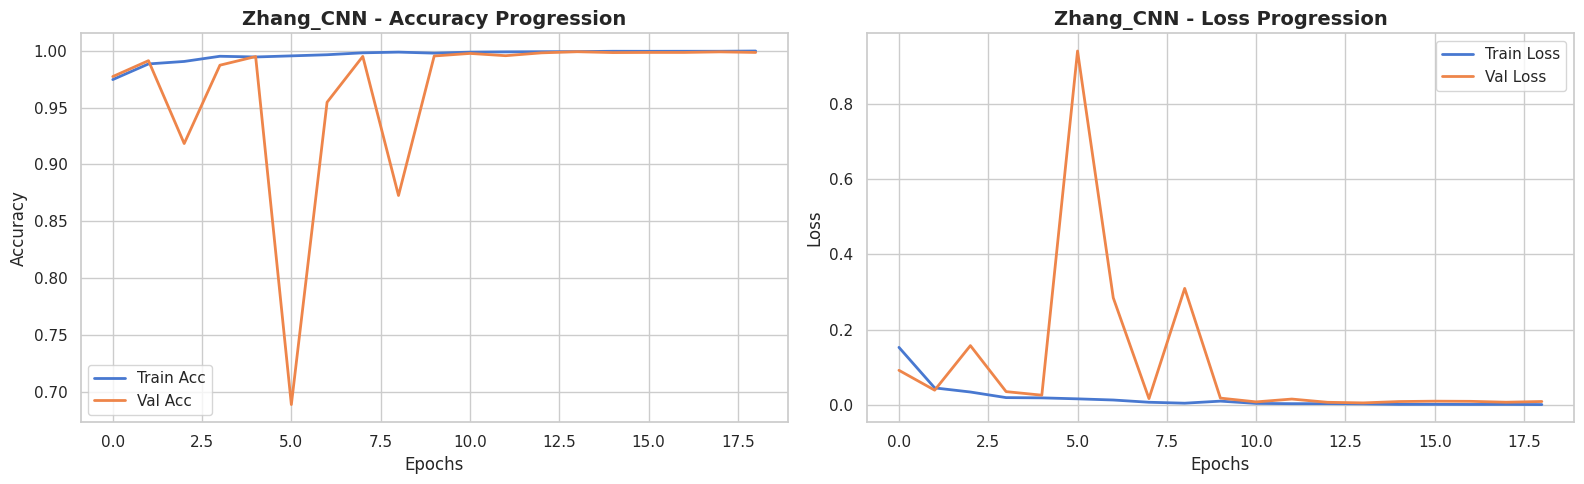

Extracting predictions for evaluation...


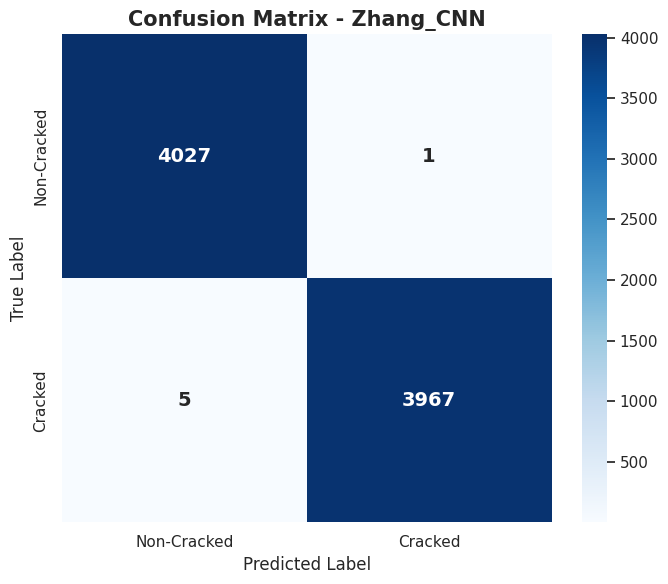


✅ Zhang_CNN Metrics | Acc: 0.9992 | Prec: 0.9997 | Rec: 0.9987 | F1: 0.9992


****************************************
>>> Processing VGG16_FineTuned on Dataset1
****************************************
✅ Found pre-trained VGG16_FineTuned in Drive! Skipping training...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


📊 Replaying training logs from saved history (11 epochs):
Epoch 1/11 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0200 - accuracy: 0.9956 - val_loss: 0.0164 - val_accuracy: 0.9958
Epoch 2/11 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0064 - accuracy: 0.9986 - val_loss: 0.0034 - val_accuracy: 0.9994
Epoch 3/11 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0055 - accuracy: 0.9987 - val_loss: 0.0143 - val_accuracy: 0.9959
Epoch 4/11 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0047 - accuracy: 0.9989 - val_loss: 0.0086 - val_accuracy: 0.9980
Epoch 5/11 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0013 - accuracy: 0.9998 - val_loss: 0.0020 - val_accuracy: 0.9996
Epoch 6/11 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0008 - accuracy: 0.9998 - val_loss: 0.0017 - val_accuracy: 0.9995
Epoch 7/11 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0006 - accuracy: 0.9999 - val_loss: 0.0024 - val_accuracy: 0.9994
Epoch 8/11 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0027 - accuracy: 0.9996 - val_loss: 0.0036 - val_accuracy: 0.9987
Epoch 9/11 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0008 - accuracy: 0.9998 - val_loss: 0.0024 - val_accur

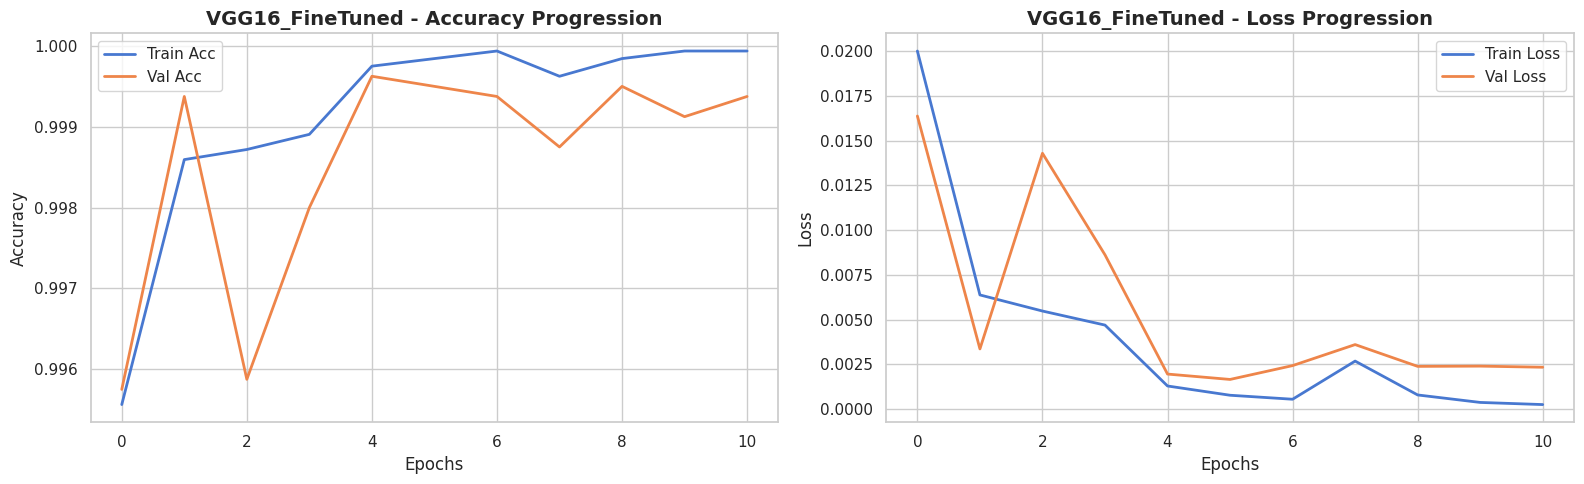

Extracting predictions for evaluation...


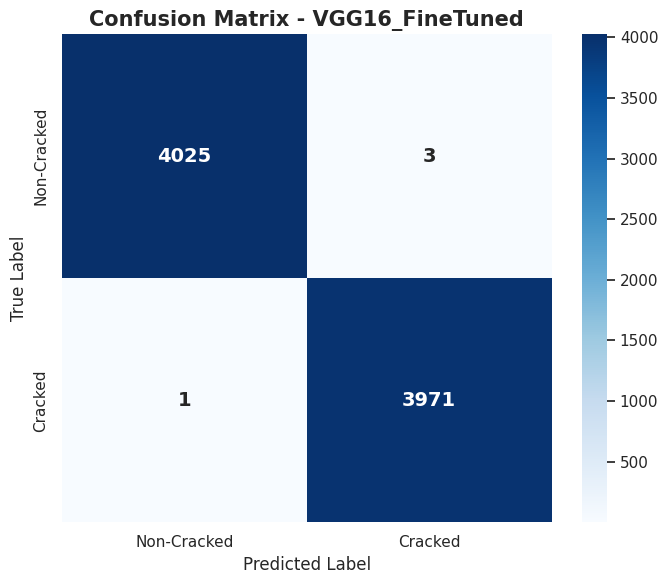


✅ VGG16_FineTuned Metrics | Acc: 0.9995 | Prec: 0.9992 | Rec: 0.9997 | F1: 0.9995


--- Generating Combined Comparison Charts for Dataset1 ---


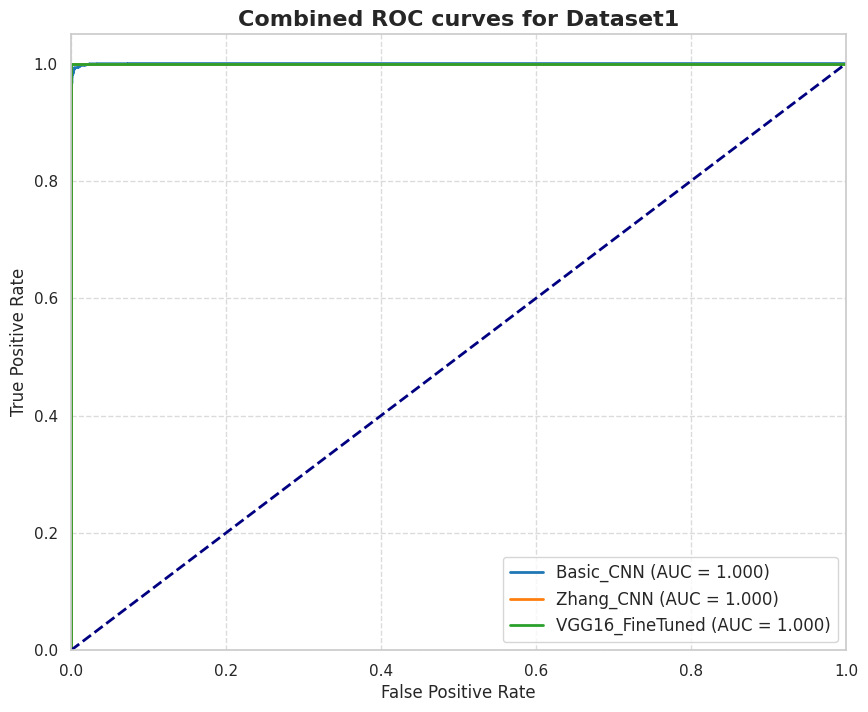


🚀 INITIATING TRAINING PIPELINE FOR Dataset2 🚀

****************************************
>>> Processing Basic_CNN on Dataset2
****************************************
✅ Found pre-trained Basic_CNN in Drive! Skipping training...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


📊 Replaying training logs from saved history (8 epochs):
Epoch 1/8 ━━━━━━━━━━━━━━━━━━━━ loss: 6.7466 - accuracy: 0.8075 - val_loss: 0.4702 - val_accuracy: 0.7906
Epoch 2/8 ━━━━━━━━━━━━━━━━━━━━ loss: 0.3730 - accuracy: 0.8567 - val_loss: 0.4243 - val_accuracy: 0.7791
Epoch 3/8 ━━━━━━━━━━━━━━━━━━━━ loss: 0.3229 - accuracy: 0.8655 - val_loss: 0.2627 - val_accuracy: 0.8986
Epoch 4/8 ━━━━━━━━━━━━━━━━━━━━ loss: 0.2986 - accuracy: 0.8773 - val_loss: 0.4411 - val_accuracy: 0.7312
Epoch 5/8 ━━━━━━━━━━━━━━━━━━━━ loss: 0.2879 - accuracy: 0.8806 - val_loss: 0.8702 - val_accuracy: 0.5392
Epoch 6/8 ━━━━━━━━━━━━━━━━━━━━ loss: 0.2642 - accuracy: 0.8900 - val_loss: 0.6021 - val_accuracy: 0.6447
Epoch 7/8 ━━━━━━━━━━━━━━━━━━━━ loss: 0.2453 - accuracy: 0.8960 - val_loss: 0.8890 - val_accuracy: 0.6562
Epoch 8/8 ━━━━━━━━━━━━━━━━━━━━ loss: 0.2116 - accuracy: 0.9036 - val_loss: 0.6214 - val_accuracy: 0.6876


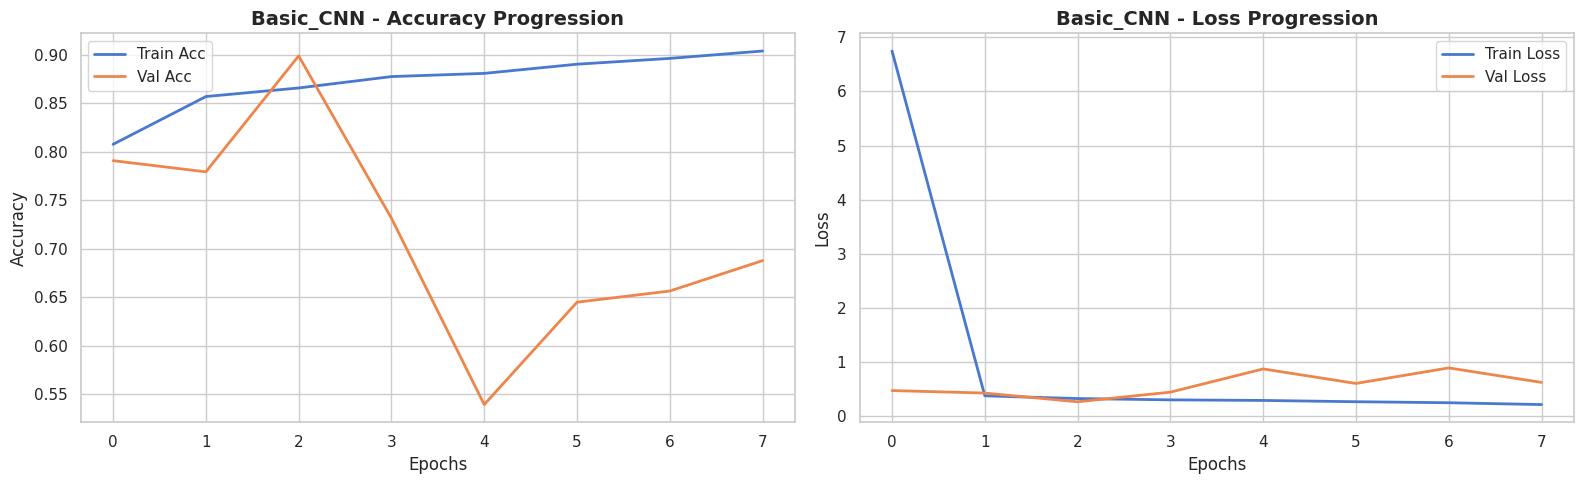

Extracting predictions for evaluation...


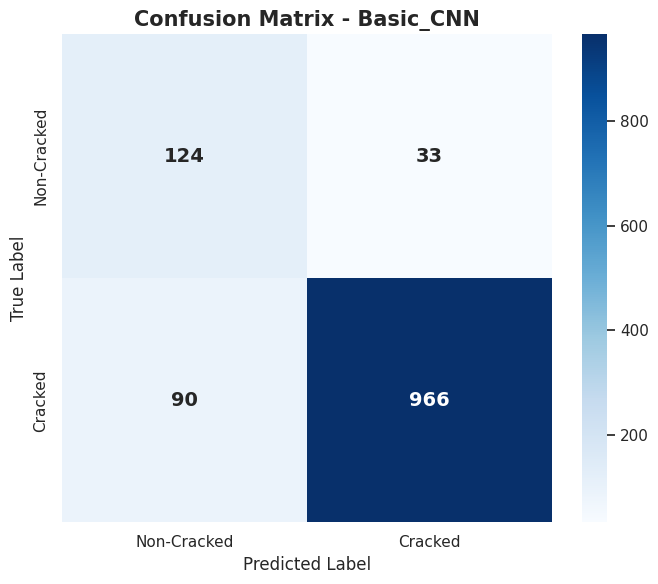


✅ Basic_CNN Metrics | Acc: 0.8986 | Prec: 0.9670 | Rec: 0.9148 | F1: 0.9401


****************************************
>>> Processing Zhang_CNN on Dataset2
****************************************
✅ Found pre-trained Zhang_CNN in Drive! Skipping training...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


📊 Replaying training logs from saved history (20 epochs):
Epoch 1/20 ━━━━━━━━━━━━━━━━━━━━ loss: 0.5961 - accuracy: 0.8713 - val_loss: 2.7989 - val_accuracy: 0.1311
Epoch 2/20 ━━━━━━━━━━━━━━━━━━━━ loss: 0.1770 - accuracy: 0.9368 - val_loss: 0.2883 - val_accuracy: 0.9019
Epoch 3/20 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0870 - accuracy: 0.9693 - val_loss: 2.7970 - val_accuracy: 0.1294
Epoch 4/20 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0852 - accuracy: 0.9710 - val_loss: 0.6367 - val_accuracy: 0.7246
Epoch 5/20 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0494 - accuracy: 0.9835 - val_loss: 0.2543 - val_accuracy: 0.9332
Epoch 6/20 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0401 - accuracy: 0.9876 - val_loss: 4.9190 - val_accuracy: 0.4608
Epoch 7/20 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0298 - accuracy: 0.9916 - val_loss: 16.0957 - val_accuracy: 0.1294
Epoch 8/20 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0265 - accuracy: 0.9920 - val_loss: 8.4993 - val_accuracy: 0.1344
Epoch 9/20 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0203 - accuracy: 0.9934 - val_loss: 5.1141 - val_accu

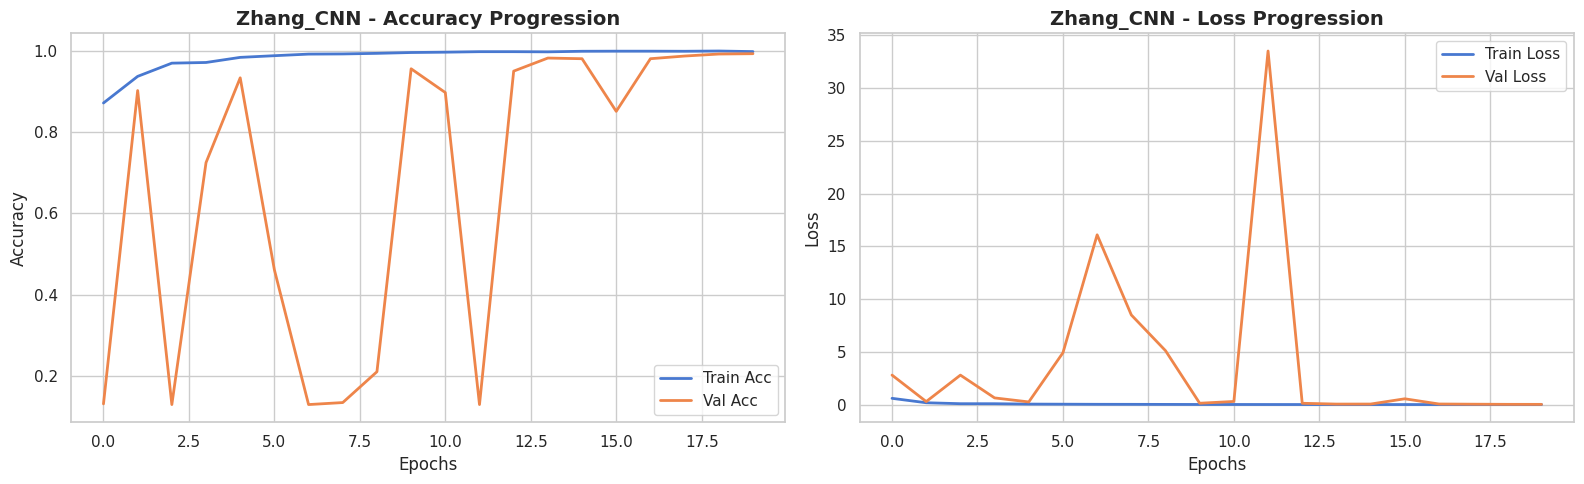

Extracting predictions for evaluation...


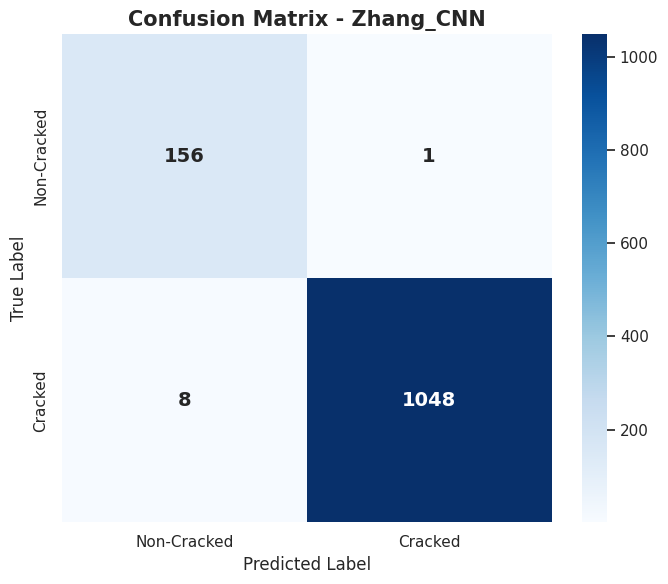


✅ Zhang_CNN Metrics | Acc: 0.9926 | Prec: 0.9990 | Rec: 0.9924 | F1: 0.9957


****************************************
>>> Processing VGG16_FineTuned on Dataset2
****************************************
✅ Found pre-trained VGG16_FineTuned in Drive! Skipping training...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


📊 Replaying training logs from saved history (6 epochs):
Epoch 1/6 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0591 - accuracy: 0.9788 - val_loss: 0.0207 - val_accuracy: 0.9951
Epoch 2/6 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0131 - accuracy: 0.9969 - val_loss: 0.0955 - val_accuracy: 0.9819
Epoch 3/6 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0060 - accuracy: 0.9984 - val_loss: 0.0877 - val_accuracy: 0.9852
Epoch 4/6 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0038 - accuracy: 0.9992 - val_loss: 0.2836 - val_accuracy: 0.9439
Epoch 5/6 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0022 - accuracy: 0.9996 - val_loss: 0.1058 - val_accuracy: 0.9819
Epoch 6/6 ━━━━━━━━━━━━━━━━━━━━ loss: 0.0017 - accuracy: 0.9998 - val_loss: 0.0949 - val_accuracy: 0.9835


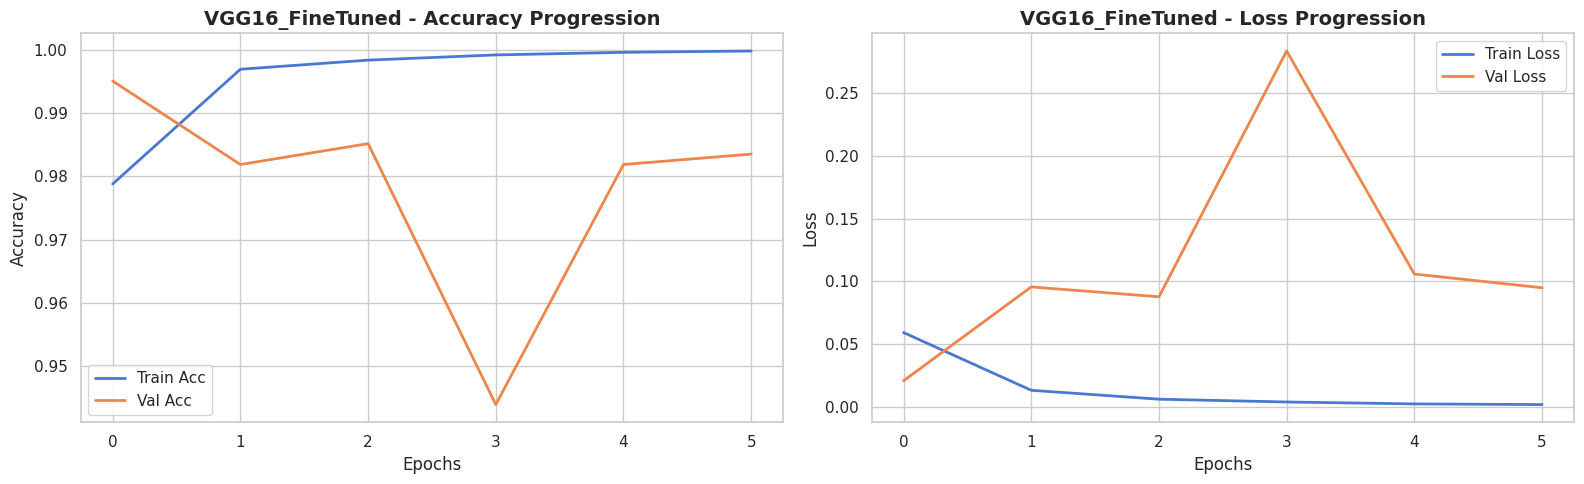

Extracting predictions for evaluation...


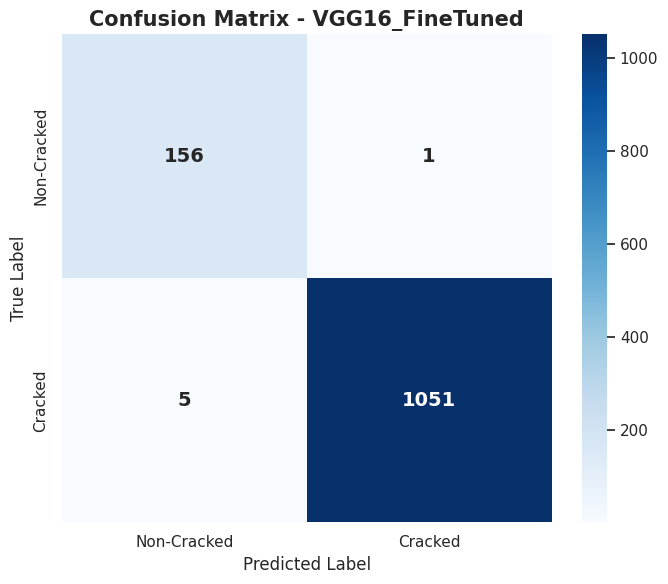


✅ VGG16_FineTuned Metrics | Acc: 0.9951 | Prec: 0.9990 | Rec: 0.9953 | F1: 0.9972


--- Generating Combined Comparison Charts for Dataset2 ---


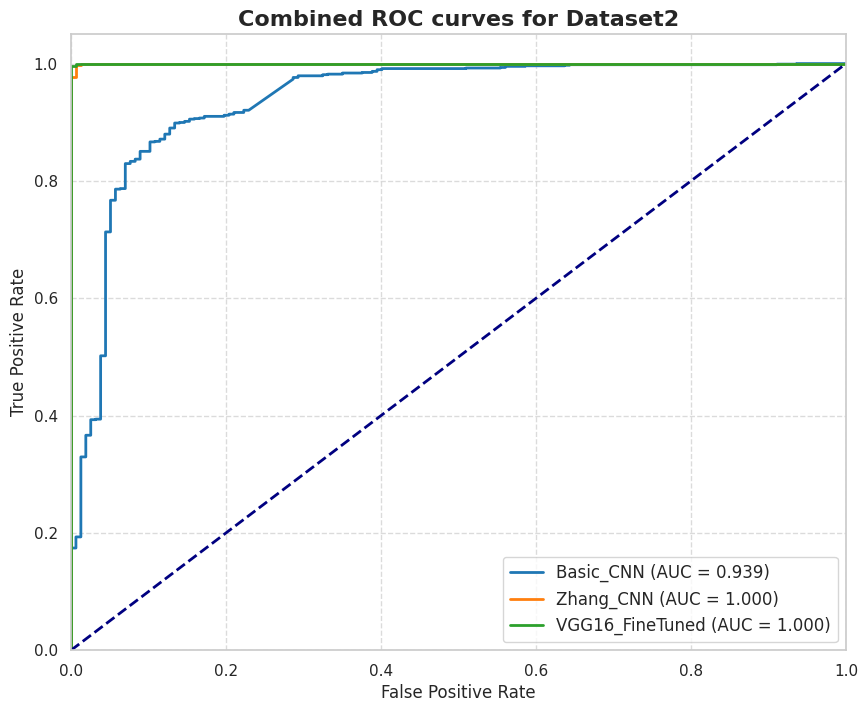

In [11]:
# ==============================================================================
# 6. MAIN PIPELINE EXECUTION
# ==============================================================================
import pandas as pd # Ensure pandas is imported

# Helper class to "trick" your existing plot_training_history function
# into reading from a loaded CSV instead of a live training session.
class MockHistory:
    def __init__(self, history_dict):
        self.history = history_dict

datasets = {
    'Dataset1': get_dataset1(),
    'Dataset2': get_dataset2()
}

all_results = {}

for ds_name, (train_ds, val_ds) in datasets.items():
    print(f"\n{'='*60}\n🚀 INITIATING TRAINING PIPELINE FOR {ds_name} 🚀\n{'='*60}")
    all_results[ds_name] = {}

    roc_data = {} # To store data for combined ROC curve

    models_dict = {
        'Basic_CNN': build_basic_cnn(),
        'Zhang_CNN': build_zhang_cnn(),
        'VGG16_FineTuned': build_vgg16_finetuned()
    }

    for model_name, model in models_dict.items():

        print(f"\n{'*'*40}\n>>> Processing {model_name} on {ds_name}\n{'*'*40}")
        save_dir = os.path.join(OUTPUT_DIR, ds_name, model_name)
        final_model_path = os.path.join(save_dir, f"{model_name}_final.keras")
        history_csv_path = os.path.join(save_dir, f"{model_name}_history.csv")

        # --- SMART RESUME: Check if model already exists ---
        if os.path.exists(final_model_path) and os.path.exists(history_csv_path):
            print(f"✅ Found pre-trained {model_name} in Drive! Skipping training...")

            # 1. Load the model
            model.load_weights(final_model_path)

            # 2. Load the history CSV and reconstruct the epoch logs
            history_df = pd.read_csv(history_csv_path)
            total_epochs = len(history_df)
            print(f"📊 Replaying training logs from saved history ({total_epochs} epochs):")

            for index, row in history_df.iterrows():
                # Formats the CSV data to look exactly like Keras training output
                log_line = f"Epoch {index + 1}/{total_epochs} ━━━━━━━━━━━━━━━━━━━━ "
                log_line += f"loss: {row['loss']:.4f} - accuracy: {row['accuracy']:.4f}"
                if 'val_loss' in row and 'val_accuracy' in row:
                    log_line += f" - val_loss: {row['val_loss']:.4f} - val_accuracy: {row['val_accuracy']:.4f}"
                print(log_line)

        else:
            print(f"🚀 Training {model_name} from scratch...")
            callbacks_list = [
                callbacks.ModelCheckpoint(os.path.join(save_dir, f"{model_name}_best.keras"),
                                          save_best_only=True, monitor='val_accuracy', mode='max'),
                callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
                callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
            ]

            history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                                callbacks=callbacks_list, verbose=1)

            # Save History to CSV
            history_df = pd.DataFrame(history.history)
            history_df.to_csv(history_csv_path, index=False)
            print(f"💾 Training history saved to: {history_csv_path}")

            # Save Final Model
            model.save(final_model_path)

        # ====================================================================
        # VISUALIZATIONS & METRICS (Runs for BOTH loaded and trained models)
        # ====================================================================

        # 1. Plot History (Reconstructs Keras history object from the DataFrame)
        mock_hist = MockHistory(history_df.to_dict(orient='list'))
        plot_training_history(mock_hist, save_dir, model_name)

        # 2. Extract Predictions
        print("Extracting predictions for evaluation...")
        y_true, y_probs = [], []
        for images, labels in val_ds:
            preds = model.predict(images, verbose=0)
            y_probs.extend(preds.flatten())
            y_true.extend(labels.numpy().flatten())

        y_true = np.array(y_true)
        y_probs = np.array(y_probs)
        y_pred = (y_probs > 0.5).astype(int)

        # 3. Save ROC data for combined graph later
        roc_data[model_name] = (y_true, y_probs)

        # 4. Plot Confusion Matrix
        plot_confusion_matrix_inline(y_true, y_pred, save_dir, model_name)

        # 5. Metrics Calculation
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        all_results[ds_name][model_name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
        print(f"\n✅ {model_name} Metrics | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}\n")

        # Aggressive memory cleanup
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # Generate the combined ROC curve for this dataset
    print(f"\n--- Generating Combined Comparison Charts for {ds_name} ---")
    plot_combined_roc_curves(ds_name, roc_data, os.path.join(OUTPUT_DIR, 'Comparisons'))


📊 FINAL PERFORMANCE COMPARISONS 📊


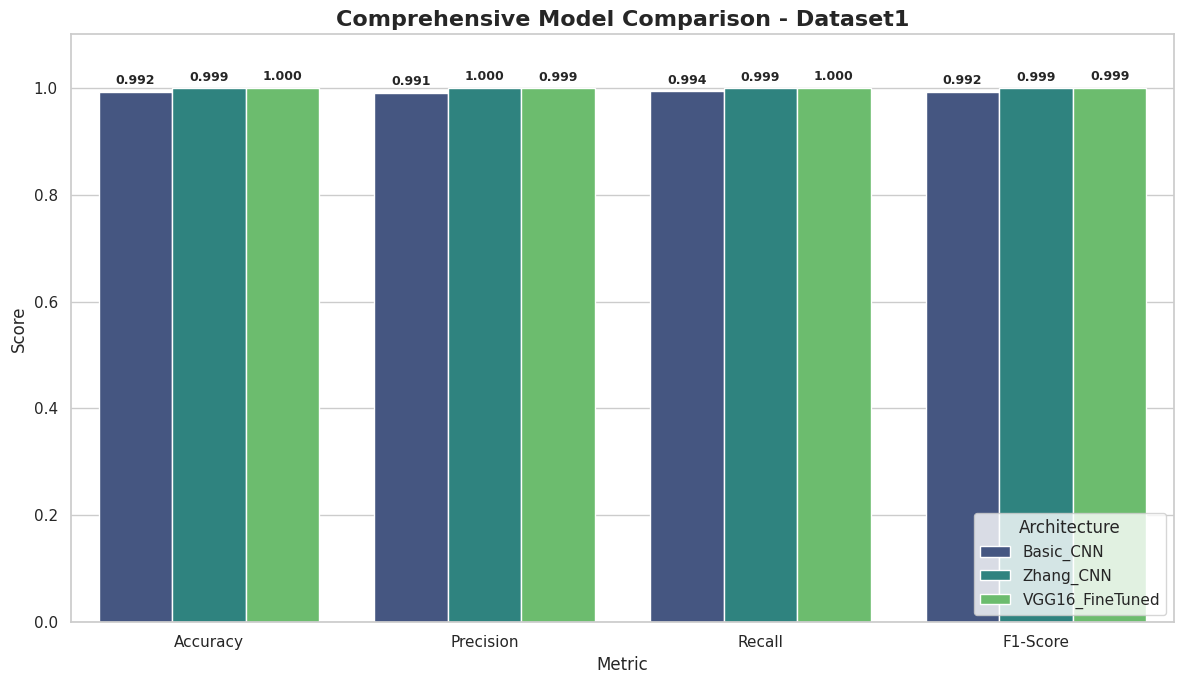

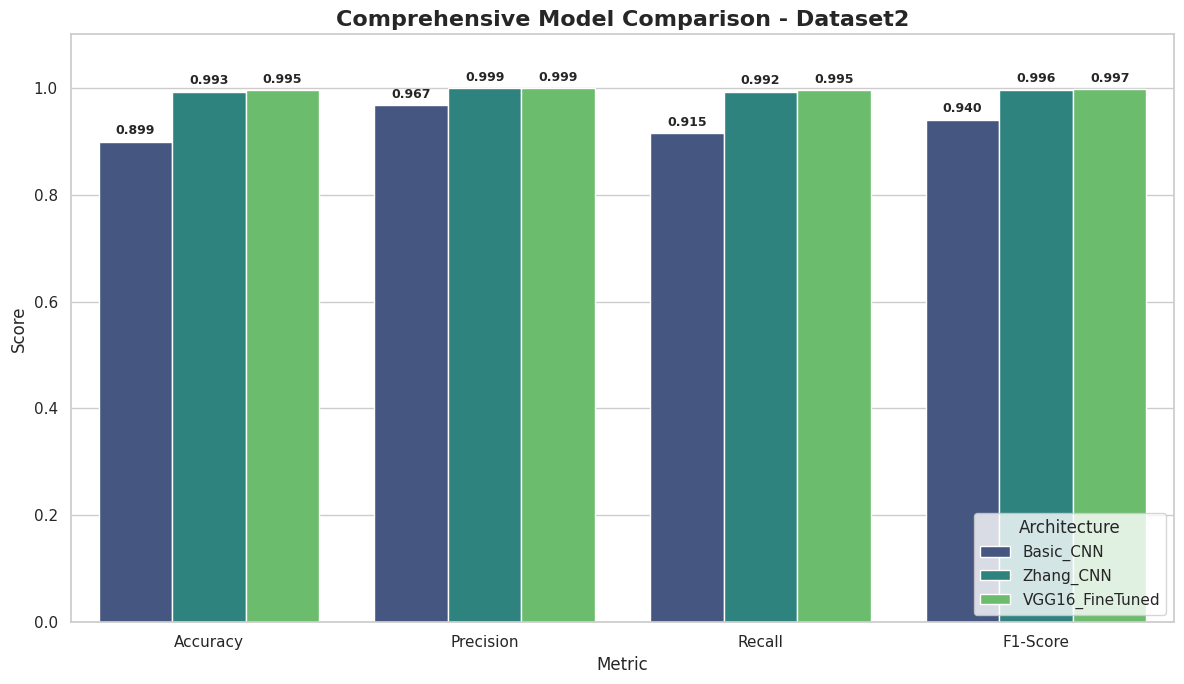


🎉 Workflow Complete! All assets, models, and beautifully rendered charts are saved in: /content/drive/MyDrive/MLProject/Output


In [14]:
# ==============================================================================
# 7. FINAL COMPARISON DASHBOARD & BAR CHARTS
# ==============================================================================
print("\n" + "="*60 + "\n📊 FINAL PERFORMANCE COMPARISONS 📊\n" + "="*60)

for ds_name, results in all_results.items():
    df = pd.DataFrame(results).T
    df.to_csv(os.path.join(OUTPUT_DIR, 'Comparisons', f'{ds_name}_metrics.csv'))

    plt.figure(figsize=(12, 7))

    # Restructure data for seaborn barplot
    df_reset = df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
    df_reset.rename(columns={'index': 'Model'}, inplace=True)

    ax = sns.barplot(data=df_reset, x='Metric', y='Score', hue='Model', palette='viridis')
    plt.title(f'Comprehensive Model Comparison - {ds_name}', fontsize=16, fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(loc='lower right', title='Architecture')

    # Annotate bars with scores
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.3f}",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 8),
                        textcoords='offset points', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'Comparisons', f'{ds_name}_BarChart.png'), dpi=300)
    plt.show() # DISPLAY IN CELL

print(f"\n🎉 Workflow Complete! All assets, models, and beautifully rendered charts are saved in: {OUTPUT_DIR}")